Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


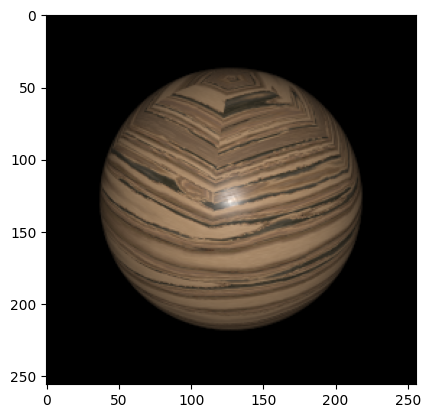

In [2]:
# SYNTHETIC SCENE SETUP
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image
from ivt.sampling import sample_sphere

from matplotlib import pyplot as plt
import torch

scene = Scene()

# material
diffuse = read_image("assets/wood_olive/wood_olive_wood_olive_diffuse.png")
specular = read_image("assets/wood_olive/wood_olive_wood_olive_specular.png")
roughness = read_image("assets/wood_olive/wood_olive_wood_olive_roughness.png")

scene.set('mat', MicrofacetBRDF(diffuse, specular, roughness))
scene.set('mesh1', Mesh.from_file("assets/meshes/sphere.obj", 'mat')) # surface to reconstruct
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('collocated', {'intensity':1}))
# scene.set('cam1', PerspectiveCamera.from_lookat(fov=40, origin=(1,0.5,0), target=(0,0,0), up=(0,1,0))) # camera

# randomly generate cameras
num_sensors = 50
fov = 40
radius = 1
target = (0,0,0)
up = (0,1,0)
for i, origin in enumerate(sample_sphere(num_sensors, radius, 'fibonacci')):
    scene.set(f'sensor {i}', PerspectiveCamera.from_lookat(fov, origin, target, up))

# render target images
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 16,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't update changes in spp, workaround here to render a higher spp target image
I_t = torch.stack([renderer(scene, sensor_ids=range(num_sensors)) for _ in range(8)]).mean(axis=0)

# Visualize a target Image
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
showimg(I_t[10])

suppose we already recovered a perfect texture

In [35]:
# downsize textures
from skimage.transform import resize
new_size = 256
diffuse1 = resize(diffuse, (new_size, new_size, diffuse.shape[2]))
specular1 = resize(diffuse, (new_size, new_size, specular.shape[2]))
roughness1 = resize(diffuse, (new_size, new_size, roughness.shape[2]))

scene = Scene()

scene.set('mat', MicrofacetBRDF(diffuse1, specular1, roughness1))
scene.set('mesh1', Mesh.from_file("assets/meshes/sphere.obj", 'mat')) # surface to reconstruct
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('collocated', {'intensity':1}))
# scene.set('cam1', PerspectiveCamera.from_lookat(fov=40, origin=(1,0.5,0), target=(0,0,0), up=(0,1,0))) # camera

# randomly generate cameras
num_sensors = 50
fov = 40
radius = 1
target = (0,0,0)
up = (0,1,0)
for i, origin in enumerate(sample_sphere(num_sensors, radius, 'fibonacci')):
    scene.set(f'sensor {i}', PerspectiveCamera.from_lookat(fov, origin, target, up))

scene['mat']['d'].shape, scene['mat']['s'].shape, scene['mat']['r'].shape

(torch.Size([256, 256, 3]),
 torch.Size([256, 256, 3]),
 torch.Size([256, 256, 1]))

In [36]:
i = 200
scene['mat']['d'][i][i][0] = 0
scene['mat']['d'][i][i][1] = 0
scene['mat']['d'][i][i][2] = 0
scene['mat'].mark_updated('d')
I1 = renderer(scene, sensor_ids=range(num_sensors))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


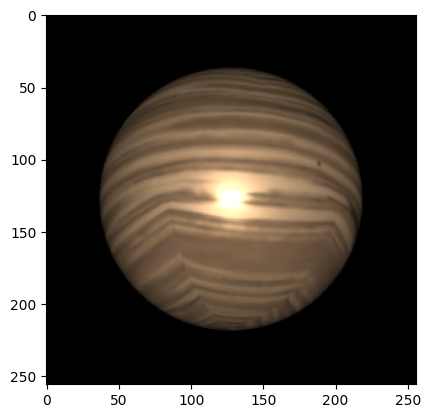

In [37]:
showimg(I1[35])